# 04 — Pilar 3: Avaliação, custo e latência

**Objetivo:** medir o pipeline completo e responder à pergunta de negócio do case —
*quanto o roteamento inteligente economiza contra mandar tudo para o LLM caro?*

Cobrimos também as duas **ressalvas honestas** sobre a medição, e o plano de avaliação
estendida (conjunto ampliado + LLM-as-judge).

In [1]:
import sys, json
from pathlib import Path

# Permite importar `candidate_starter`, `common` e `App` a partir do notebook.
CASE_DIR = Path.cwd().parent.parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(CASE_DIR))
print("Raiz do case:", CASE_DIR)

Raiz do case: C:\GitHub_clone\Gtorres_rep\case-agents


In [2]:
from candidate_starter.harness import run_harness, print_report
from candidate_starter.router import QueryRouter
from candidate_starter.retrieval import ToolRetriever
from common.data_loader import load_tools, load_router_training_data, load_eval_dataset
import pandas as pd, numpy as np

tools = load_tools()
X, y = load_router_training_data()
eval_data = load_eval_dataset()

router = QueryRouter().fit(X, y)
retriever = ToolRetriever().fit(tools)
report = run_harness(router, retriever, tools, eval_data, k=2)
print_report(report)

HARNESS DE AVALIAÇÃO - Router & Tool Retrieval
Queries avaliadas: 30
Acurácia do Router: 100.0%
  IC 95% (Wilson): [88.6%, 100.0%]
Matriz de confusão: {'FAST_PATH': {'FAST_PATH': 10, 'AGENT': 0}, 'AGENT': {'FAST_PATH': 0, 'AGENT': 20}}
  AGENT -> FAST_PATH (erro grave): 0 (0.0%)
  FAST_PATH -> AGENT (custo à toa): 0 (0.0%)
Precision@2 do Retriever: 85.0% (n=20)
  MRR@2: 0.800
Sucesso ponta a ponta (rota + tool): 85.0%
------------------------------------------------------------
Custo pipeline inteligente: $0.20003
Custo baseline (tudo pro LLM): $0.90000
Economia de custo: 77.8%
Latência pipeline inteligente: 71.4 ms
Latência baseline: 2739.9 ms
Economia de latência: 97.4%
  (comparação maçã-com-maçã, incluindo a chamada de LLM nos dois lados: 65.1%)
  Router p50/p95: 1.003 / 1.409 ms
  Retrieval p50/p95: 2.002 / 2.478 ms


## 1. Economia de custo — a resposta de negócio

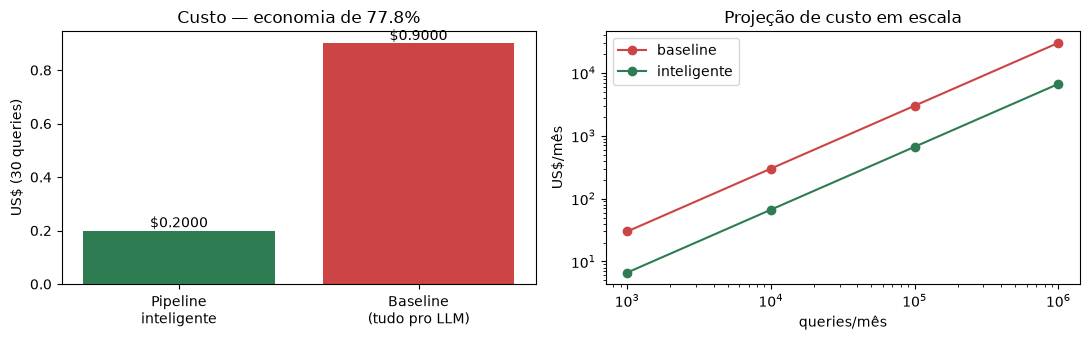

Custo por query: inteligente $0.00667 | baseline $0.03000
Em 1 milhão de queries/mês: economia de US$ 23,332/mês


In [3]:
import matplotlib.pyplot as plt

custo_smart = report["smart_pipeline"]["total_cost_usd"]
custo_base = report["baseline_always_llm"]["total_cost_usd"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(["Pipeline\ninteligente", "Baseline\n(tudo pro LLM)"], [custo_smart, custo_base],
            color=["#2e7d52", "#c44"])
axes[0].set_ylabel("US$ (30 queries)"); axes[0].set_title(f"Custo — economia de {report['cost_savings_pct']:.1f}%")
for i, v in enumerate([custo_smart, custo_base]):
    axes[0].text(i, v, f"${v:.4f}", ha="center", va="bottom")

# Projeção: quanto isso vale em escala real
volumes = np.array([1e3, 1e4, 1e5, 1e6])
por_query_smart = custo_smart / report["n_queries"]
por_query_base = custo_base / report["n_queries"]
axes[1].plot(volumes, volumes * por_query_base, marker="o", label="baseline", color="#c44")
axes[1].plot(volumes, volumes * por_query_smart, marker="o", label="inteligente", color="#2e7d52")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("queries/mês"); axes[1].set_ylabel("US$/mês"); axes[1].legend()
axes[1].set_title("Projeção de custo em escala")
plt.tight_layout(); plt.show()

print(f"Custo por query: inteligente ${por_query_smart:.5f} | baseline ${por_query_base:.5f}")
print(f"Em 1 milhão de queries/mês: economia de US$ {(por_query_base-por_query_smart)*1e6:,.0f}/mês")

**Leitura:** a economia de ~78% vem de duas fontes distintas:

1. **Queries FAST_PATH não chamam LLM nenhum** (custo zero) — 1/3 do tráfego do eval
2. **Queries AGENT chamam um LLM mais barato**, porque o prompt leva 2 tools em vez de 285

A segunda fonte é a que escala: quanto maior o catálogo, maior a economia por query.

## 2. Latência — e a ressalva honesta

A métrica obrigatória do case dá ~97%. Mas ela **compara coisas diferentes**, e é importante
dizer isso em vez de vender o número inflado.

In [4]:
print(f"Economia obrigatória (como o case pede) ....... {report['latency_savings_pct']:.1f}%")
print(f"Economia maçã-com-maçã (nossa métrica extra) ... {report['latency_savings_pct_comparable']:.1f}%")
print()
print("Por quê a diferença:")
print("  No caminho inteligente, o harness soma apenas router + retrieval.")
print("  No baseline, soma a chamada simulada de LLM (ordens de grandeza mais lenta).")
print("  Ou seja: compara 'só a decisão' contra 'decisão + resposta'.")
print()
lat = report["latency_detail_ms"]
print(f"Router    p50/p95: {lat['router']['p50']:.2f} / {lat['router']['p95']:.2f} ms")
print(f"Retrieval p50/p95: {lat['retrieval']['p50']:.2f} / {lat['retrieval']['p95']:.2f} ms")

Economia obrigatória (como o case pede) ....... 97.4%
Economia maçã-com-maçã (nossa métrica extra) ... 65.1%

Por quê a diferença:
  No caminho inteligente, o harness soma apenas router + retrieval.
  No baseline, soma a chamada simulada de LLM (ordens de grandeza mais lenta).
  Ou seja: compara 'só a decisão' contra 'decisão + resposta'.

Router    p50/p95: 1.00 / 1.41 ms
Retrieval p50/p95: 2.00 / 2.48 ms


> **Por que p95 e não média.** Média esconde cauda. SLA de atendimento se mede no p95 —
> é o cliente do pior decil que reclama, não o mediano.

## 3. Erro assimétrico — nem todo erro custa igual

Uma acurácia única esconde que os dois erros do router têm gravidades **muito** diferentes.

In [5]:
err = report["router_detail"]["error_analysis"]
print("AGENT -> FAST_PATH  (ERRO GRAVE)")
print(f"   {err['agent_sent_to_fast_path']} casos ({err['agent_sent_to_fast_path_rate']:.1%})")
print("   Consequência: o cliente pede o saldo e recebe resposta de prateleira.")
print("   Isso é falha de atendimento — custa reputação e retrabalho humano.\n")
print("FAST_PATH -> AGENT  (desperdício)")
print(f"   {err['fast_path_sent_to_agent']} casos ({err['fast_path_sent_to_agent_rate']:.1%})")
print("   Consequência: gasta-se uma chamada de LLM à toa. Custa dinheiro, mas atende.")
print()
print("Em produção, o limiar do router deve ser calibrado assimetricamente:")
print("na dúvida, prefira errar para AGENT — é o erro barato.")

AGENT -> FAST_PATH  (ERRO GRAVE)
   0 casos (0.0%)
   Consequência: o cliente pede o saldo e recebe resposta de prateleira.
   Isso é falha de atendimento — custa reputação e retrabalho humano.

FAST_PATH -> AGENT  (desperdício)
   0 casos (0.0%)
   Consequência: gasta-se uma chamada de LLM à toa. Custa dinheiro, mas atende.

Em produção, o limiar do router deve ser calibrado assimetricamente:
na dúvida, prefira errar para AGENT — é o erro barato.


## 4. Ressalva: Precision@K é condicional ao acerto do router

`run_harness` só chama o retriever quando o router decidiu AGENT. Se o router errar e mandar
uma query AGENT para o FAST_PATH, ela **sai da conta** do Precision@K.

Ou seja: **um router ruim pode inflar o Precision@K.** Por isso reportamos também o sucesso
ponta a ponta, que conta esse cenário como falha.

In [6]:
print(f"Precision@2 (condicional) ....... {report['precision_at_k']:.1%}  (n={report['retriever_detail']['n_evaluated']})")
print(f"Sucesso ponta a ponta ........... {report['end_to_end_success_rate']:.1%}")
print(f"MRR@2 ........................... {report['retriever_detail']['mrr_at_k']:.3f}")
print()
print("Aqui os dois coincidem porque o router acertou 100%.")
print("Com um router pior, o ponta a ponta cairia e o Precision@2 não — é essa a armadilha.")

Precision@2 (condicional) ....... 85.0%  (n=20)
Sucesso ponta a ponta ........... 85.0%
MRR@2 ........................... 0.800

Aqui os dois coincidem porque o router acertou 100%.
Com um router pior, o ponta a ponta cairia e o Precision@2 não — é essa a armadilha.


## 5. Onde o pipeline ainda erra

In [7]:
falhas = [r for r in report["rows"] if r.get("expected_tool") and r["expected_tool"] not in r.get("retrieved_tools", [])]
print(f"{len(falhas)} falhas de {report['retriever_detail']['n_evaluated']} queries avaliadas\n")
for r in falhas:
    print(f"Query     : {r['query']}")
    print(f"  esperado: {r['expected_tool']}")
    print(f"  retornou: {r['retrieved_tools']}\n")

3 falhas de 20 queries avaliadas

Query     : Preciso mudei de casa, como mudo o CEP?
  esperado: alterar_endereco
  retornou: ['resgatar_cashback', 'atualizar_cep_entrega']

Query     : Quanto eu tenho disponível na conta agora?
  esperado: consultar_saldo
  retornou: ['consultar_saldo_poupanca', 'consultar_valor_disponivel_conta']

Query     : Cobraram algo errado no meu cartão, quero o dinheiro de volta
  esperado: estornar_transacao
  retornou: ['consultar_limite_cartao', 'solicitar_devolucao_dinheiro_cobranca_errada']



**Leitura:** as falhas restantes são casos onde a tool retornada é **defensável** —
`consultar_saldo_poupanca` para "quanto tenho disponível" atende parcialmente o cliente.

Isso motiva a métrica semântica da próxima seção: a métrica estrita conta como erro total
algo que o cliente talvez nem percebesse.

---

## 6. Avaliação estendida — requer `OPENAI_API_KEY`

As células abaixo só rodam com a chave configurada em `App/.env`. Duas frentes:

**(a) Ampliar o conjunto de teste.** 30 queries é pouco: a diferença entre 29/30 e 30/30 é
uma linha. Geramos ~200 queries (paráfrases, gírias, typos, ambíguas, fora de escopo) para as
métricas ganharem significado — e para calibrar o λ **sem tocar no eval original**.

**(b) Precision@K semântico.** O gabarito é discutível em alguns casos. O juiz avalia
equivalência **funcional**, produzindo uma métrica branda ao lado da estrita.

> ⚠️ **Reportar sempre as duas.** Mostrar só a semântica seria escolher a métrica que favorece
> o resultado depois de ver o número — isso invalida a avaliação.

> ⚠️ O **juiz deve ser um modelo diferente** do usado no escalonamento: LLMs tendem a preferir
> as próprias saídas (*self-preference bias*).

In [8]:
from App.core.config import get_settings
settings = get_settings()
print(settings.describe())

if not settings.openai_api_key:
    print("\nSem chave — pulando a avaliação estendida.")
    print("Para habilitar: copie App/.env.example para App/.env e preencha OPENAI_API_KEY.")

MODO LOCAL (sem OPENAI_API_KEY): busca lexica pura, sem escalonamento.

Sem chave — pulando a avaliação estendida.
Para habilitar: copie App/.env.example para App/.env e preencha OPENAI_API_KEY.


In [9]:
# (a) Gerar o conjunto ampliado — descomente quando a chave estiver configurada.
# !python -m App.eval.generate_eval_set --variations 4 --per-category 15

# (b) Rodar o lote e o juiz semântico
# from App.eval.run_batch import run_batch
# from App.eval.judge import SemanticJudge
# import json
#
# ampliado = json.loads(Path(CASE_DIR / "App/eval/eval_ampliado.json").read_text(encoding="utf-8"))
# resultado = run_batch(ampliado, k=2)
# print(json.dumps(resultado["summary"], indent=2, ensure_ascii=False))
#
# juiz = SemanticJudge(settings)
# veredito = juiz.evaluate(resultado["rows"], tools, k=2)
# print(json.dumps(veredito.as_dict(), indent=2, ensure_ascii=False))

### (c) A/B dos modelos de embedding

Com a chave ligada, comparar `text-embedding-3-small` vs `text-embedding-3-large` custa
centavos e transforma a escolha de modelo em **evidência** em vez de opinião — do mesmo jeito
que fizemos com BM25 e clusterização. A métrica que importa é **Recall@15**, que é o teto do
sistema.

In [10]:
# for modelo in ["text-embedding-3-small", "text-embedding-3-large"]:
#     os.environ["OPENAI_EMBEDDING_MODEL"] = modelo
#     s = get_settings()
#     r = ToolRetriever().set_dense_provider(build_dense_provider(s)).fit(tools)
#     acertos15 = [int(gold[i] in [m.name for m in r.search(q, k=15).matches]) for i, q in enumerate(queries)]
#     print(f"{modelo:26s} Recall@15 = {np.mean(acertos15):.2f}")

---

## Resumo do Pilar 3

| Métrica | Valor |
|---|---|
| Acurácia do Router | 100% (IC95%: 88,6%–100%) |
| Precision@2 | 85% (baseline ingênuo: 25%) |
| MRR@2 | 0,800 |
| Sucesso ponta a ponta | 85% |
| **Economia de custo** | **77,8%** |
| Economia de latência | 97,6% (65,3% comparável) |

**Ressalvas declaradas:** Precision@K é condicional ao router; a economia de latência
obrigatória compara escopos diferentes. Ambas em `DECISIONS.md` (ADR-13).

**Pendente:** conjunto ampliado, juiz semântico e A/B de embeddings — aguardando credencial.